# Język Python w Analizie Danych
# Lab08 - Mistrzostw Świata - Sprawozdanie

Autor: Piotr Przymus 127902

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Wczytanie danych
Wczytałem oba pliki CSV do obiektów `pandas.DataFrame` i sprawdziłem ich rozmiar oraz podstawową strukturę.

In [145]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print("Zbiór treningowy:", train.shape)
print("Zbiór testowy (2026):", test.shape)
print("\nEdycje turnieju w danych treningowych:", sorted(train["version"].unique()))

display(train.head())
display(test.head())

Zbiór treningowy: (192, 24)
Zbiór testowy (2026): (48, 24)

Edycje turnieju w danych treningowych: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,52700000.0,57,581.0,29.2,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,777200000.0,9,746.0,27.8,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,48030000.0,42,612.0,27.1,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,858500000.0,1,827.0,27.1,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,18400000.0,26,683.0,24.7,2,1,1,0,0,0,0,0,0,0


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,1290000000,1,1877.32,26.7,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,1150000000,2,1876.40,27.2,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,575000000,3,1874.81,27.9,18,15,10,10,6,6,NaN,NaN,NaN,NaN
3,2026,England,Europe,0,82,23,26,6,7,1,1300000000,4,1825.97,26.8,16,13,8,10,3,1,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,841000000,5,1763.83,27.1,8,5,4,3,2,0,NaN,NaN,NaN,NaN


Zbiór treningowy zawiera 192 obserwacje (32 drużyny × 6 turniejów), a testowy 48 drużyn biorących udział w MŚ 2026. Każdy wiersz opisuje jedną reprezentację przed rozpoczęciem turnieju.

## EDA - Typy danych i braki
Sprawdziłem typy kolumn, liczbę brakujących wartości oraz rozkład zmiennych docelowych w zbiorze treningowym.

In [146]:
print(train.info())
print("\nBraki w train:")
print(train.isnull().sum())
print("\nBraki w test (oczekiwane - brak etykiet):")
print(test.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          192 non-null    int64  
 1   team                             192 non-null    str    
 2   continent                        192 non-null    str    
 3   is_host                          192 non-null    int64  
 4   goals_scored_last_4y             192 non-null    int64  
 5   goals_received_last_4y           192 non-null    int64  
 6   wins_last_4y                     192 non-null    int64  
 7   losses_last_4y                   192 non-null    int64  
 8   draws_last_4y                    192 non-null    int64  
 9   world_cup_titles_before          192 non-null    int64  
 10  squad_total_market_value_eur     160 non-null    float64
 11  fifa_rank_pre_tournament         192 non-null    int64  
 12  fifa_points_pre_tournament       

Wszystkie kolumny poza nazwami krajów i kontynentów są typu numerycznego.
W `train` braki występują tylko w kolumnie `squad_total_market_value`. W `test` jedyne "braki" danych występują w kolumnach `winner`, `finalist`, `semi_finalist` oraz `quarter_finalist` - są one zmiennymi docelowymi.

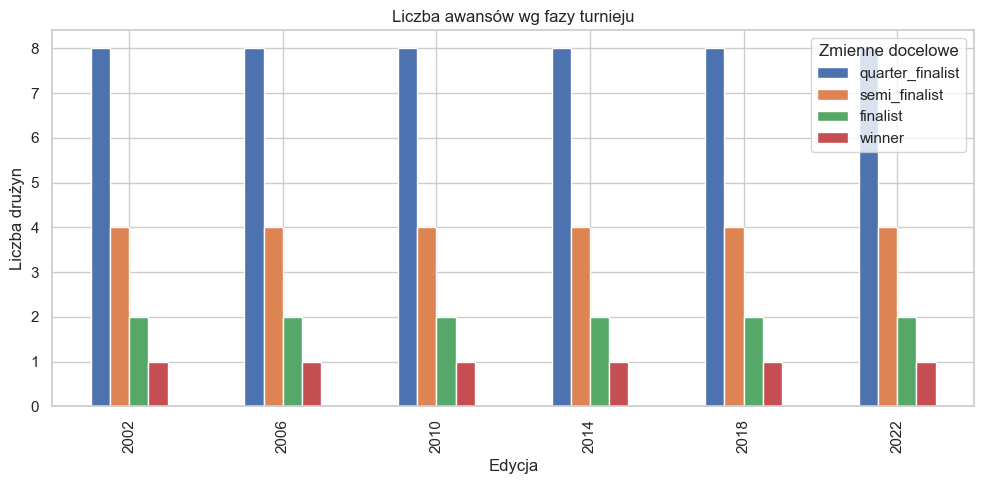

In [147]:
target_cols = ["quarter_finalist", "semi_finalist", "finalist", "winner"]

train.groupby("version")[target_cols].sum().plot(kind="bar", figsize=(10, 5))
plt.title("Liczba awansów wg fazy turnieju")
plt.xlabel("Edycja")
plt.ylabel("Liczba drużyn")
plt.legend(title="Zmienne docelowe")
plt.tight_layout()
plt.show()

Zmienne docelowe są binarne (0/1). W każdej edycji MŚ awansuje dokładnie 8 drużyn do ćwierćfinałów, 4 do półfinałów, 2 do finału i 1 wygrywa turniej - stąd silna nierównowaga klas (tylko 6 zwycięzców na 192 obserwacje itp.).

## EDA - Historia turniejów
Przeanalizowałem, które reprezentacje osiągały najlepsze wyniki w danych historycznych oraz rozkład drużyn według kontynentów.

Mistrzowie świata w danych treningowych:
     version       team
13      2006      Italy
42      2018     France
64      2022  Argentina
124     2010      Spain
142     2014    Germany
162     2002     Brazil


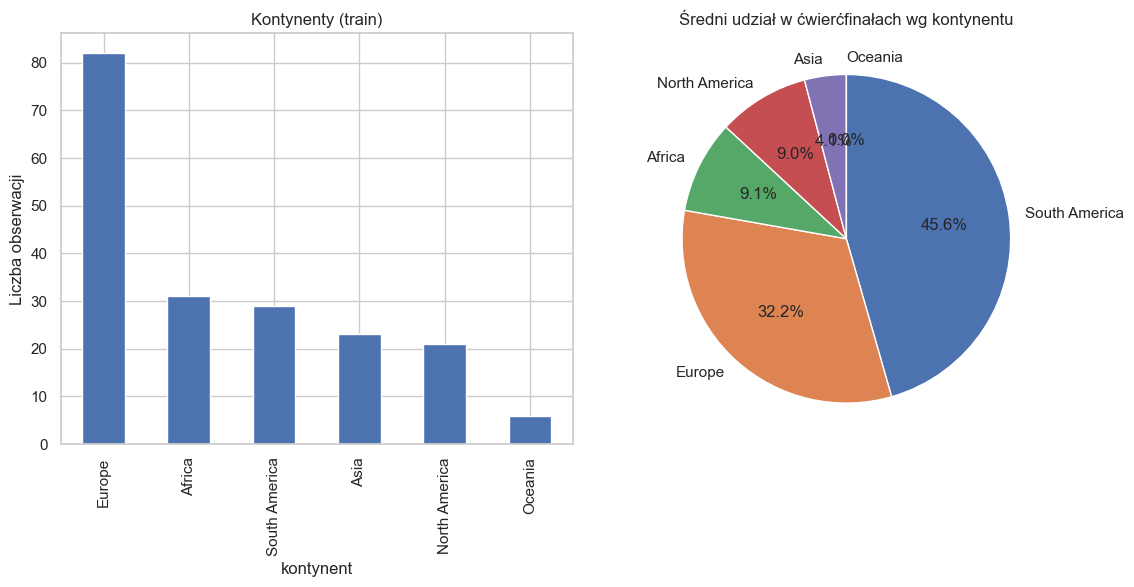

In [148]:
winners = train[train["winner"] == 1][["version", "team"]]
print("Mistrzowie świata w danych treningowych:")
print(winners.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

train["continent"].value_counts().plot(kind="bar", ax=axes[0], title="Kontynenty (train)")
axes[0].set_ylabel("Liczba obserwacji")
axes[0].set_xlabel("kontynent")

quarter_by_continent = train.groupby("continent")["quarter_finalist"].mean().sort_values(ascending=False)
pie_labels = [f"{name}" for name, rate in quarter_by_continent.items()]
axes[1].pie(
    quarter_by_continent,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
axes[1].set_title("Średni udział w ćwierćfinałach wg kontynentu")

plt.tight_layout()
plt.show()

Z wykresu kołowego możemy odczytać, że praktycznie połowa historycznych ćwierćfinalistów pochodziła z Ameryki Południowej.

<Figure size 1200x500 with 0 Axes>

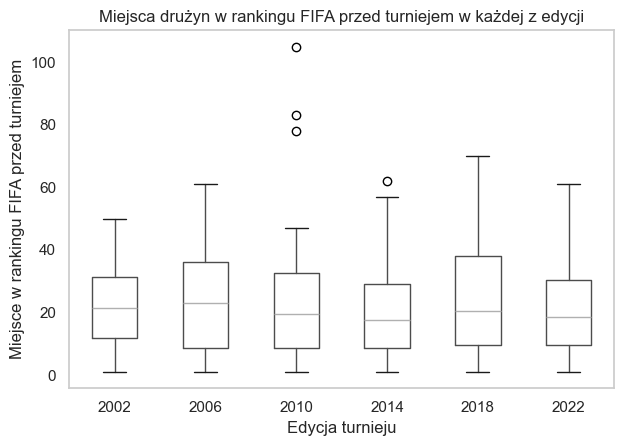

In [149]:
plt.figure(figsize=(12, 5))
train.boxplot(column="fifa_rank_pre_tournament", by="version", grid=False)
plt.title("Miejsca drużyn w rankingu FIFA przed turniejem w każdej z edycji")
plt.suptitle("")
plt.xlabel("Edycja turnieju")
plt.ylabel("Miejsce w rankingu FIFA przed turniejem")
plt.tight_layout()
plt.show()

Warto zauważyć, że w 2010 i 2014 roku było kilka punktów oddalonych - tymi punktami oddalonymi są odpowiednio Nowa Zelandia (78), RPA (83) Korea Północna (105) w 2010 oraz Australia na 62 miejscu w 2014.

## EDA - Cechy numeryczne
Zbadałem statystyki wybranych cech numerycznych oraz korelację z awansem do ćwierćfinałów.

In [150]:
numeric_cols = [
    "fifa_rank_pre_tournament",
    "fifa_points_pre_tournament",
    "squad_total_market_value_eur",
    "squad_avg_age",
    "goals_scored_last_4y",
    "wins_last_4y",
]

train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fifa_rank_pre_tournament,192.0,2.354167e+01,1.821450e+01,1.00,9.00,2.000000e+01,34.0,1.050000e+02
fifa_points_pre_tournament,192.0,9.541655e+02,3.675446e+02,285.00,670.50,8.240000e+02,1182.5,1.841300e+03
squad_total_market_value_eur,160.0,3.433053e+08,3.489032e+08,6270000.00,93857500.00,2.179400e+08,412975000.0,1.620000e+09
squad_avg_age,192.0,2.724964e+01,1.092351e+00,23.92,26.56,2.722500e+01,28.0,2.978000e+01
goals_scored_last_4y,192.0,8.458333e+01,2.373178e+01,28.00,66.00,8.350000e+01,102.0,1.560000e+02
wins_last_4y,192.0,2.604688e+01,6.912534e+00,8.00,21.00,2.500000e+01,31.0,4.800000e+01


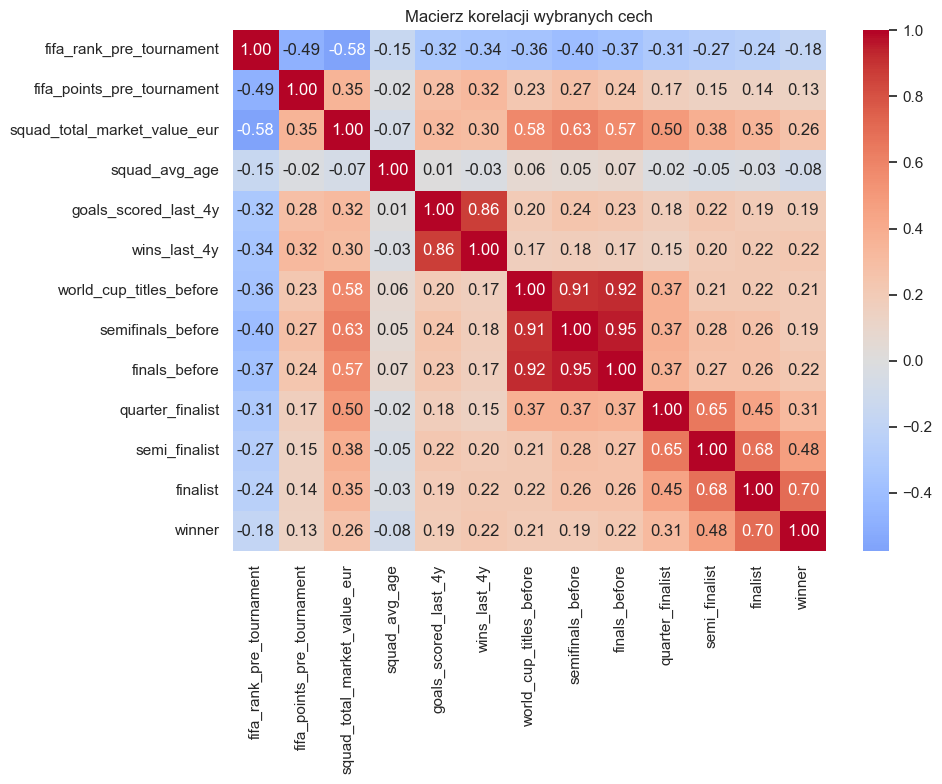

In [151]:
corr_cols = numeric_cols + ["world_cup_titles_before", "semifinals_before", "finals_before"] + target_cols
corr = train[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Macierz korelacji wybranych cech")
plt.tight_layout()
plt.show()

Między dawniejszą wygraną turnieju, udziałem w finale i udziałem w półfinale występuje bardzo silna korelacja dodatnia (0.90+). Można też zauważyć, że ilość strzelonych goli przez ostatnie 4 lata silnie wpływa na ilość wygranych w tym samym okresie (0.86). Te zmienne mają również umiarkowaną korelację dodatnią ze zmienną dotyczącą rynkowej wartości składu. Naturalnie między udziałem w finale danego turnieju i zwycięstwem w nim również jest silna korelacja. Umiarkowana korelacja ujemna występuje również m.in. między `fifa_rank_pre_tournament` a `fifa_points_pre_tournament` (im więcej punktów, tym lepsze miejsce w rankingu).

## Przygotowanie danych

Braki w kolumnie z wartością rynkową składu uzupełnię medianą.

In [152]:
median_market_value = train["squad_total_market_value_eur"].median()

train["squad_total_market_value_eur"] = train["squad_total_market_value_eur"].fillna(median_market_value)

print(f"Uzupełniono braki w wartości składu medianą: {median_market_value:,.0f}")
print("Braki po uzupełnieniu (train):", train["squad_total_market_value_eur"].isnull().sum())

Uzupełniono braki w wartości składu medianą: 217,940,000
Braki po uzupełnieniu (train): 0


Dodatkowo, dla względów estetycznych, poprawiam nazwę kraju Curacao (w zbiorze testowym zapisana jako "Cura?o")

In [153]:
test["team"] = test["team"].replace({"Cura?o" : "Curacao"})

Zdefiniowałem cechy wejściowe (X) oraz cztery zmienne docelowe (y). Zmienne kategoryczne `team` i `continent` koduję za pomocą **OneHotEncoder**. Kolumna `version` służy jedynie do chronologii turniejów i nie trafia do modelu.

In [154]:
CATEGORICAL_FEATURES = ["team", "continent"]
TARGET_COLS = ["quarter_finalist", "semi_finalist", "finalist", "winner"]
EXCLUDED_COLS = set(TARGET_COLS + ["version"])

FEATURES = [c for c in train.columns if c not in EXCLUDED_COLS]
NUM_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]


def make_preprocessor():
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, NUM_FEATURES),
        ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ])


def make_model_pipeline(model):
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", model),
    ])


X_train = train[FEATURES]
X_test = test[FEATURES]

print("Cechy kategoryczne:", CATEGORICAL_FEATURES)
print("Cechy numeryczne:", NUM_FEATURES)
print("Liczba cech przed kodowaniem:", len(FEATURES))

Cechy kategoryczne: ['team', 'continent']
Cechy numeryczne: ['is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before']
Liczba cech przed kodowaniem: 19


## Porównanie modeli
Zamiast jednego modelu, postanowiłem porównać cztery modele klasyfikacji binarnej:
- **Random Forest**,
- **Gradient Boosting**,
- **Logistic Regression**,
- **XGBoost**.

Każdy model trenuję w **Pipeline** z preprocessorem (`team` + `continent` przez OneHot, cechy numeryczne przez imputację i skalowanie). Dla każdej fazy turnieju (ćwierćfinały, półfinały, finał, zwycięstwo) trenuję osobny klasyfikator. Jakość oceniam 5-krotną walidacją krzyżową metryką **ROC AUC**, a następnie wybieram jeden algorytm o najwyższym średnim AUC do predykcji MŚ 2026.

In [155]:
target_cols = ["quarter_finalist", "semi_finalist", "finalist", "winner"]


def predict_positive_score(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if hasattr(model, "named_steps") and "model" in model.named_steps:
            classes = list(model.named_steps["model"].classes_)
            if 1 in classes:
                return proba[:, classes.index(1)]
        return proba[:, 1]
    return np.clip(model.predict(X), 0, 1)


def get_models():
    candidates = {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            random_state=42,
        ),
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss",
            scale_pos_weight=3,
        ),
    }
    return candidates


cv_results = []
fitted_models = {}

for model_name, model in get_models().items():
    for target in target_cols:
        y = train[target]
        pipeline = make_model_pipeline(clone(model))
        cv_scores = cross_val_score(pipeline, X_train, y, cv=5, scoring="roc_auc")
        fitted = make_model_pipeline(clone(model))
        fitted.fit(X_train, y)
        fitted_models[(model_name, target)] = fitted

        cv_results.append({
            "Model": model_name,
            "Faza": target,
            "ROC AUC": round(cv_scores.mean(), 3),
            "Odch. std.": round(cv_scores.std(), 3),
        })

cv_df = pd.DataFrame(cv_results)
print("Wyniki walidacji krzyżowej (ROC AUC):")
display(cv_df)

Wyniki walidacji krzyżowej (ROC AUC):


,Model,Faza,ROC AUC,Odch. std.
0,Random Forest,quarter_finalist,0.769,0.074
1,Random Forest,semi_finalist,0.762,0.108
2,Random Forest,finalist,0.794,0.118
3,Random Forest,winner,0.866,0.098
4,Gradient Boosting,quarter_finalist,0.720,0.109
5,Gradient Boosting,semi_finalist,0.699,0.152
6,Gradient Boosting,finalist,0.536,0.263
7,Gradient Boosting,winner,0.614,0.204
8,Logistic Regression,quarter_finalist,0.718,0.113
9,Logistic Regression,semi_finalist,0.781,0.101


Porównanie modeli - ROC AUC wg fazy turnieju:


Faza,quarter_finalist,semi_finalist,finalist,winner
Model,,,,
Gradient Boosting,0.720,0.699,0.536,0.614
Logistic Regression,0.718,0.781,0.706,0.848
Random Forest,0.769,0.762,0.794,0.866
XGBoost,0.700,0.728,0.688,0.828



Podsumowanie jakości modeli:


,Średni ROC AUC,Odch. std.
Model,,
Random Forest,0.798,0.048
Logistic Regression,0.763,0.065
XGBoost,0.736,0.064
Gradient Boosting,0.642,0.084


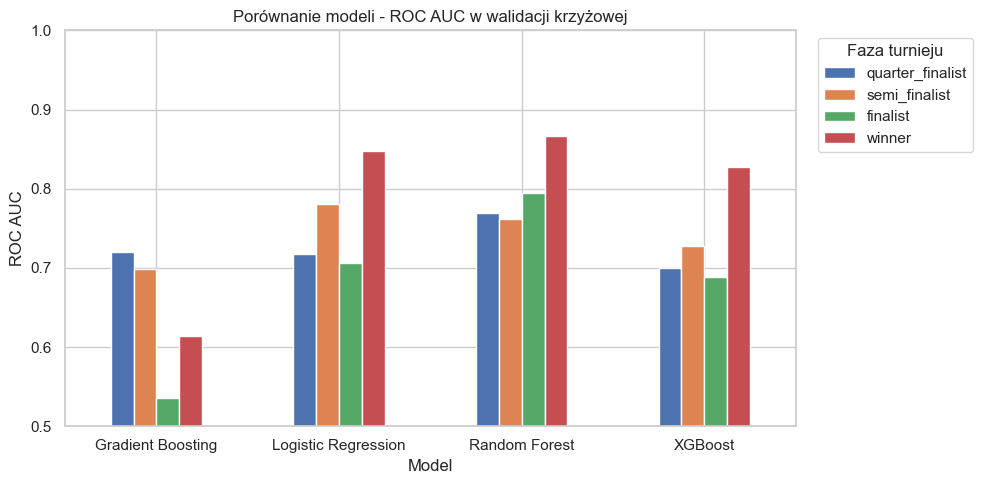

In [156]:
cv_pivot = cv_df.pivot(index="Model", columns="Faza", values="ROC AUC")
cv_pivot = cv_pivot[target_cols]
print("Porównanie modeli - ROC AUC wg fazy turnieju:")
display(cv_pivot)

model_summary = cv_df.groupby("Model")["ROC AUC"].agg(["mean", "std"]).round(3)
model_summary = model_summary.sort_values("mean", ascending=False)
model_summary.columns = ["Średni ROC AUC", "Odch. std."]
print("\nPodsumowanie jakości modeli:")
display(model_summary)

cv_pivot.plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Porównanie modeli - ROC AUC w walidacji krzyżowej")
plt.ylabel("ROC AUC")
plt.ylim(0.5, 1.0)
plt.legend(title="Faza turnieju", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Ranking średniego ROC AUC w walidacji krzyżowej: **Random Forest** (0,798) > **Logistic Regression** (0,763) > **XGBoost** (0,736) > **Gradient Boosting** (0,642). **Random Forest** wygrywa w ćwierćfinałach (0,769), półfinałach (0,762) i finale (0,794), a także osiąga najwyższy wynik dla `winner` (0,866). **Logistic Regression** plasuje się tuż za RF, natomiast **Gradient Boosting** radzi sobie najsłabiej, zwłaszcza z rzadszymi klasami (`finalist` 0,536, `winner` 0,614).

## Wybór modelu do predykcji
Na podstawie średniego ROC AUC w walidacji krzyżowej wybrałem jeden algorytm do wszystkich faz turnieju: **Random Forest** (średni AUC = 0,798). Dla każdej fazy (`quarter_finalist`, `semi_finalist`, `finalist`, `winner`) trenuję osobny model tego samego typu - różni się tylko zmienna docelowa.

In [157]:
overall_best_name = model_summary.index[0]
overall_best_auc = model_summary.loc[overall_best_name, "Średni ROC AUC"]

print(f"Model do predykcji MŚ 2026: {overall_best_name} (średni ROC AUC = {overall_best_auc})")

best_models = {}
best_model_names = {}

for target in target_cols:
    best_model_names[target] = overall_best_name
    best_models[target] = fitted_models[(overall_best_name, target)]

Model do predykcji MŚ 2026: Random Forest (średni ROC AUC = 0.798)


Dla wybranego modelu (**Random Forest**) sprawdziłem, które cechy mają największy wpływ na predykcję zwycięzcy turnieju.

Top 10 cech - najlepszy model zwycięzcy (Random Forest):


,cecha,ważność
8,fifa_rank_pre_tournament,0.103464
11,world_cup_participations_before,0.084317
7,squad_total_market_value_eur,0.083719
13,round16_before,0.079106
3,wins_last_4y,0.066721
12,groups_passed_before,0.062517
14,quarterfinals_before,0.060600
10,squad_avg_age,0.054961
15,semifinals_before,0.050232
1,goals_scored_last_4y,0.049305


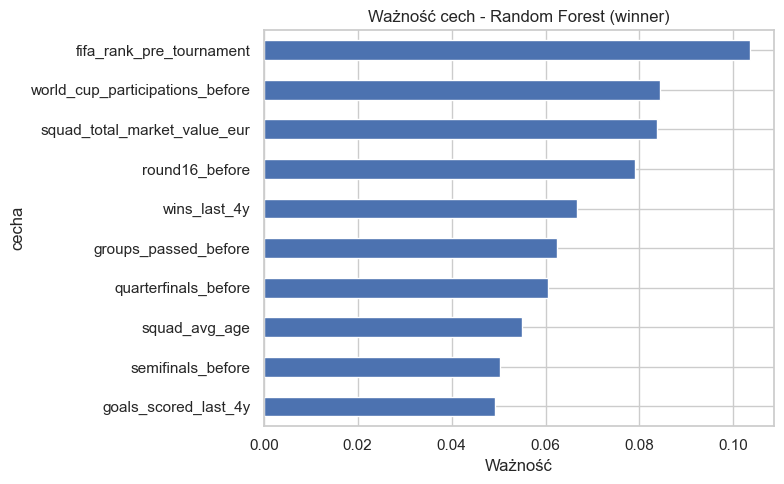

In [158]:
def get_encoded_feature_names(pipeline):
    preprocessor = pipeline.named_steps["preprocess"]
    names = list(NUM_FEATURES)
    cat_pipe = preprocessor.named_transformers_["cat"]
    onehot = cat_pipe.named_steps["onehot"]
    cat_names = list(onehot.get_feature_names_out(CAT_FEATURES))
    names.extend(cat_names)
    return np.array(names)


winner_model = best_models["winner"]
winner_model_name = best_model_names["winner"]
model = winner_model.named_steps["model"]

importances = model.feature_importances_

feature_names = get_encoded_feature_names(winner_model)

importance = pd.DataFrame({
    "cecha": feature_names,
    "ważność": importances,
}).sort_values("ważność", ascending=False)

print(f"Top 10 cech - najlepszy model zwycięzcy ({winner_model_name}):")
display(importance.head(10))

importance.head(10).plot(x="cecha", y="ważność", kind="barh", legend=False, figsize=(8, 5))
plt.title(f"Ważność cech - {winner_model_name} (winner)")
plt.xlabel("Ważność")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Dla **Random Forest** najważniejsze cechy numeryczne to: `fifa_rank_pre_tournament`, `world_cup_participations_before`, `squad_total_market_value_eur`, `round16_before` - można stwierdzić, że to dosyć realistyczne.

## Predykcja dla MŚ 2026
Na podstawie wybranego modelu (**Random Forest**) obliczyłem prawdopodobieństwa awansu (`P(faza)`) dla każdej z 48 drużyn:

- `score_quarter_finalist` = `P(quarter_finalist)`
- `score_semi_finalist` = `P(quarter_finalist)` × `P(semi_finalist)`
- `score_finalist` = poprzedni wynik × `P(finalist)`
- `score_winner` = poprzedni wynik × `P(winner)`

Wyboru drużyn dokonałem kaskadowo: 8 ćwierćfinalistów -> z nich 4 półfinalistów -> z nich 2 finalistów -> 1 zwycięzca.

In [159]:
predictions = test[["team", "continent", "fifa_rank_pre_tournament", "is_host"]].copy()
predictions["model"] = overall_best_name

for target in target_cols:
    predictions[f"P({target})"] = predict_positive_score(best_models[target], X_test)

predictions["score_quarter_finalist"] = predictions["P(quarter_finalist)"]
predictions["score_semi_finalist"] = (
    predictions["P(quarter_finalist)"] * predictions["P(semi_finalist)"]
)
predictions["score_finalist"] = (
    predictions["score_semi_finalist"] * predictions["P(finalist)"]
)
predictions["score_winner"] = (
    predictions["score_finalist"] * predictions["P(winner)"]
)

predictions = predictions.sort_values("score_winner", ascending=False)
predictions.head(10)

,team,continent,fifa_rank_pre_tournament,is_host,model,P(quarter_finalist),P(semi_finalist),P(finalist),P(winner),score_quarter_finalist,score_semi_finalist,score_finalist,score_winner
0,France,Europe,1,0,Random Forest,0.675,0.650,0.625,0.450,0.675,0.438750,0.274219,0.123398
2,Argentina,South America,3,0,Random Forest,0.780,0.600,0.490,0.425,0.780,0.468000,0.229320,0.097461
1,Spain,Europe,2,0,Random Forest,0.670,0.515,0.390,0.395,0.670,0.345050,0.134570,0.053155
6,Netherlands,Europe,7,0,Random Forest,0.680,0.480,0.425,0.225,0.680,0.326400,0.138720,0.031212
3,England,Europe,4,0,Random Forest,0.630,0.565,0.340,0.185,0.630,0.355950,0.121023,0.022389
4,Portugal,Europe,5,0,Random Forest,0.640,0.420,0.355,0.095,0.640,0.268800,0.095424,0.009065
7,Morocco,Africa,8,0,Random Forest,0.575,0.555,0.355,0.065,0.575,0.319125,0.113289,0.007364
15,Uruguay,South America,17,0,Random Forest,0.455,0.350,0.195,0.160,0.455,0.159250,0.031054,0.004969
8,Belgium,Europe,9,0,Random Forest,0.525,0.355,0.240,0.090,0.525,0.186375,0.044730,0.004026
9,Germany,Europe,10,0,Random Forest,0.360,0.375,0.215,0.120,0.360,0.135000,0.029025,0.003483


In [163]:
final_prediction = predictions.copy()
for target in target_cols:
    final_prediction[f"pred_{target}"] = 0

stage_labels = {
    "quarter_finalist": "Ćwierćfinały",
    "semi_finalist": "Półfinały",
    "finalist": "Finał",
    "winner": "Zwycięzca",
}
score_cols = {
    "quarter_finalist": "score_quarter_finalist",
    "semi_finalist": "score_semi_finalist",
    "finalist": "score_finalist",
    "winner": "score_winner",
}
stage_k = {"quarter_finalist": 8, "semi_finalist": 4, "finalist": 2, "winner": 1}

qf_idx = final_prediction.nlargest(stage_k["quarter_finalist"], "score_quarter_finalist").index
final_prediction.loc[qf_idx, "pred_quarter_finalist"] = 1

semi_candidates = final_prediction[final_prediction["pred_quarter_finalist"] == 1]
semi_idx = semi_candidates.nlargest(stage_k["semi_finalist"], "score_semi_finalist").index
final_prediction.loc[semi_idx, "pred_semi_finalist"] = 1

final_candidates = final_prediction[final_prediction["pred_semi_finalist"] == 1]
final_idx = final_candidates.nlargest(stage_k["finalist"], "score_finalist").index
final_prediction.loc[final_idx, "pred_finalist"] = 1

winner_candidates = final_prediction[final_prediction["pred_finalist"] == 1]
winner_idx = winner_candidates.nlargest(stage_k["winner"], "score_winner").index
final_prediction.loc[winner_idx, "pred_winner"] = 1

for target in target_cols:
    selected = final_prediction[final_prediction[f"pred_{target}"] == 1].sort_values(
        score_cols[target], ascending=False
    )
    print(f"=== Prognoza: {stage_labels[target]} ===")
    print(selected[["team", score_cols[target]]].to_string(index=False))
    print()

stage_table = pd.DataFrame({
    "Faza": [stage_labels[t] for t in target_cols],
    "Drużyny": [
        ", ".join(
            final_prediction.loc[final_prediction[f"pred_{t}"] == 1]
            .sort_values(score_cols[t], ascending=False)["team"]
        )
        for t in target_cols
    ],
})
print("Podsumowanie ścieżki turnieju:")
stage_table

=== Prognoza: Ćwierćfinały ===
       team  score_quarter_finalist
  Argentina                   0.780
Netherlands                   0.680
     France                   0.675
      Spain                   0.670
   Portugal                   0.640
    England                   0.630
    Morocco                   0.575
     Sweden                   0.570

=== Prognoza: Półfinały ===
     team  score_semi_finalist
Argentina              0.46800
   France              0.43875
  England              0.35595
    Spain              0.34505

=== Prognoza: Finał ===
     team  score_finalist
   France        0.274219
Argentina        0.229320

=== Prognoza: Zwycięzca ===
  team  score_winner
France      0.123398

Podsumowanie ścieżki turnieju:


,Faza,Drużyny
0,Ćwierćfinały,"Argentina, Netherlands, France, Spain, Portuga..."
1,Półfinały,"Argentina, France, England, Spain"
2,Finał,"France, Argentina"
3,Zwycięzca,France


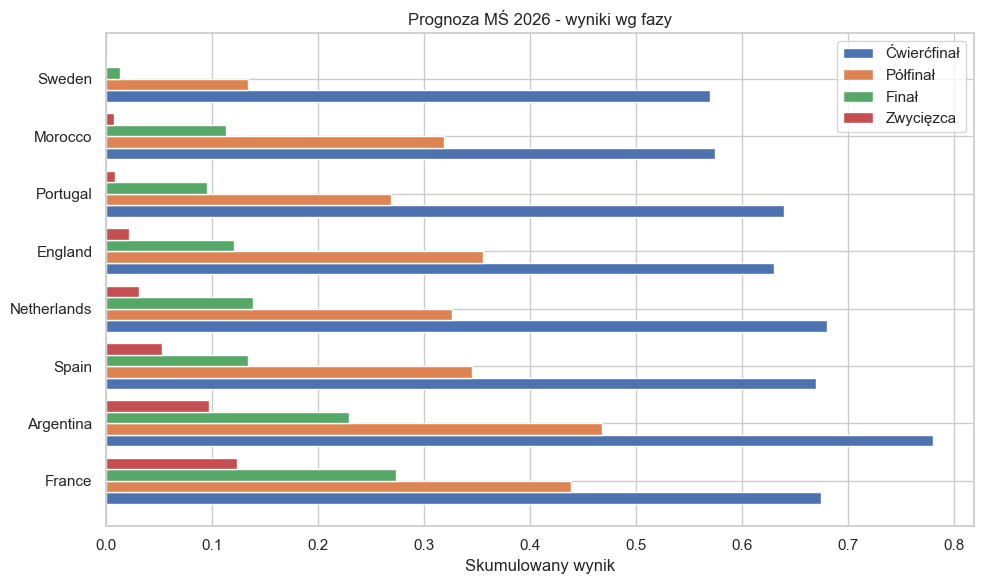

In [165]:
viz_teams = final_prediction[final_prediction["pred_quarter_finalist"] == 1].sort_values(
    "score_winner", ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(viz_teams))
width = 0.2

ax.barh(x - 1.5 * width, viz_teams["score_quarter_finalist"], width, label="Ćwierćfinał")
ax.barh(x - 0.5 * width, viz_teams["score_semi_finalist"], width, label="Półfinał")
ax.barh(x + 0.5 * width, viz_teams["score_finalist"], width, label="Finał")
ax.barh(x + 1.5 * width, viz_teams["score_winner"], width, label="Zwycięzca")

ax.set_yticks(x)
ax.set_yticklabels(viz_teams["team"])
ax.set_xlabel("Skumulowany wynik")
ax.set_title("Prognoza MŚ 2026 - wyniki wg fazy")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

| Faza | Drużyny i ich skumulowane wyniki|
|------|-------------------------------------------|
| Ćwierćfinały | Argentyna (0,78), Holandia (0,68), Francja (0,68), Hiszpania (0,67), Portugalia (0,64), Anglia (0,63), Maroko (0,58), Szwecja (0,57) |
| Półfinały | Argentyna (0,47), Francja (0,44), Anglia (0,36), Hiszpania (0,35) |
| Finał | Francja (0,27), Argentyna (0,23) |
| Zwycięzca | **Francja** (0,12) |

Według zbudowanego modelu, teraźniejsze MŚ powinna wygrać **Francja**, a w finale spotka się ona z Argentyną - takie spotkanie byłoby powtórką finału z 2022 roku, jedynie z innym zakończeniem :). Taka sytuacja nie jest nierealistyczna - obie drużyny faktycznie cały czas utrzymują się na najwyższym poziomie. Przewidziany zestaw ćwierćfinalistów również jest możliwy.

## Wnioski końcowe

#### EDA

Historycznie drużyny, które docierają do późniejszych faz, wyróżniają się wyższym rankingiem FIFA, większą wartością składu, lepszą formą z ostatnich 4 lat oraz bogatszym doświadczeniem w MŚ. To potwierdza intuicję sportową, ale jednocześnie pokazuje, że wiele cech opisuje te same reprezentacje - np. silna korelacja między wcześniejszymi półfinałami, finałami i tytułami oznacza, że model ma ograniczoną liczbę niezależnych informacji o „sile” drużyny.

Zmienne docelowe są **skrajnie niezbalansowane**: w każdej edycji tylko 8 z 32 drużyn dociera do ćwierćfinałów, a zwycięzca jest jeden. Na 192 obserwacje historyczne przypada zaledwie 6 przykładów klasy „mistrz świata”. To utrudnia uczenie się rzadkich zdarzeń i powoduje że sensowne wzorce nie muszą przekładać się na trafny typ jednego konkretnego turnieju.

#### Wynik najlepszego modelu

ROC AUC na poziomie ok. 0,80 dla Random Forest oznacza, że model lepiej niż losowo ustawia drużyny w kolejności „kto ma większą szansę awansu”, zwłaszcza na etapach ćwierć- i półfinałowych. Przy fazach `finalist` i `winner` metryka może wyglądać jeszcze lepiej, mimo że praktyczne przewidzenie mistrza jest najtrudniejsze: w walidacji krzyżowej model wielokrotnie widzi te same historyczne potęgi, a liczba pozytywnych przykładów jest mała. Wysoki AUC nie oznacza, że model dobrze przewidzi MŚ 2026 - walidacja krzyżowa ocenia przeszłość na podobnych danych, ale nie przyszły turniej z elementem losowości.

#### Format 48 drużyn vs dane z 32 reprezentacji

Zbiór treningowy pochodzi z turniejów 32-drużynowych (2002–2022). MŚ 2026 ma 48 uczestników - teraz odbywa się inna liczba meczów, inna faza grupowa, inna konkurencja o miejsca w ćwierćfinale. Model nie widział takiego układu w danych uczących, więc część jego wniosków to ekstrapolacja poza znany system.

Dodatkowo w puli 2026 są reprezentacje słabiej reprezentowane w historii (lub w ogóle nieobecne w zbiorze treningowym) - dla nich cecha `team` nie niesie wyuczonego wzorca, a decyzja opiera się głównie na rankingu, formie i wartości składu. To zwiększa niepewność prognozy w porównaniu z typowymi faworytami.

#### Predykcja a rzeczywistość sportowa

Wynik modelu (np. Francja jako zwycięzca, finał z Argentyną) warto traktować jako uporządkowaną listę faworytów, a raczej nie prognozę wyniku turnieju. Piłka nożna na poziomie pucharowym ma wysoką wariancję: pojedynczy mecz, kontuzje, kartki, rzuty karne, celność strzałów czy podań - jest wiele czynników, których zbiór danych nie zawiera.

Sensowniejsze jest pytanie „kto plasuje się w gronie 8 realnych kandydatów do zajścia daleko w turnieju?” niż „kto wygra mundial?”. Model może dobrze wskazać elitę, a jednocześnie źle wskazać mistrza, ale też i odwrotnie: trafny typ zwycięzcy przy słabym rankingu ćwierćfinalistów byłby przypadkiem, nie dowodem jakości.